# Iterative Radiomics-Guided Region Growing Algorithm



## Objective

Implement an iterative region growing algorithm using voxel-based PyRadiomics features on SPECT tumor images.

## Algorithm Overview

1. **Load SPECT DICOM Study**: Import full 3D DICOM series using SimpleITK
2. **Extract & Display Coronal Slice**: Select a specific coronal plane for analysis
3. **Define Working ROI**: Crop the coronal slice to the region of interest
4. **Create Initial Lesion Mask**: Apply intensity thresholding to identify potential lesion
5. **Compute Reference Radiomic Map**: Extract voxel-based Median map inside initial ROI (ROI0)
6. **Establish Statistical Limits**: Use ROI0 distribution as fixed reference (mean ± k*std)
7. **Iterative Region Growing**:
   - Dilate current ROI to generate candidate voxels (corona)
   - Compute voxel-based Median for dilated region
   - Classify each voxel: accept if within statistical bounds
   - Update ROI with accepted voxels
   - Repeat for N iterations
8. **Generate Results & Visualizations**

## Key Implementation Details

- **Radiomic Feature**: `firstorder.Median` (voxel-based)
- **Reference Distribution**: Fixed throughout all iterations
- **PyRadiomics Coordinate Handling**: Automatic reconstruction from bounding-box to full-image coordinates
- **Configurable Parameters**: Threshold percentage, k-value, number of iterations

In [20]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk
from pathlib import Path
from scipy.ndimage import binary_dilation
from radiomics import featureextractor
import matplotlib.patches as patches
import pydicom

## Variable parameters

### 1. **Threshold**
### 2. **k_value**
### 3. **Caracteristica radiomica**

In [21]:
# ==============================================================================
# 2. CONFIGURATION & PARAMETERS
# ==============================================================================

# Data paths
DATA_DIR = Path("PSMAB37")
SPECT_DIR = DATA_DIR / "SPECT"

# Imaging parameters
CORONAL_SLICE = 137
ROI_CROP = (220, 140)        # (row_start, col_start)

# Thresholding parameters
THRESHOLD_PERCENTILE = 0.65  # Initial ROI = 70% of maximum intensity

# ------------------------------------------------------------------------------
# Radiomic feature
# ------------------------------------------------------------------------------

FEATURE_CLASS = "ngtdm"  # Options: "firstorder", "ngtdm"
FEATURE_NAME = "Coarseness"  # Original implementation

# Examples:
#
# FEATURE_CLASS = "firstorder"
# FEATURE_NAME  = "Median"         # Original implementation
#
# FEATURE_CLASS = "ngtdm"
# FEATURE_NAME  = "Coarseness"     # Best alternative feature

FEATURE_KEY = f"original_{FEATURE_CLASS}_{FEATURE_NAME}"

# ------------------------------------------------------------------------------
# Statistical voxel acceptance criterion
# ------------------------------------------------------------------------------

ACCEPTANCE_METHOD = "mad"  # Options: "mean_std", "mad", "percentile", "tukey"

# Available methods:
# "mean_std"    -> Mean ± K·Std
# "mad"         -> Median ± ROBUST_K·MAD
# "percentile"  -> 5th–95th percentiles
# "tukey"       -> Tukey fences (1.5 × IQR)

K_VALUE = 10                 # Only for "mean_std"
ROBUST_K = 2.5                 # Only for "mad"
PERCENTILE_LOW = 5           # Only for "percentile"
PERCENTILE_HIGH = 95         # Only for "percentile"

# Algorithm parameters
NUM_ITERATIONS = 20

print("Configuration loaded:")
print(f"  - SPECT directory: {SPECT_DIR}")
print(f"  - Coronal slice: {CORONAL_SLICE}")
print(f"  - ROI crop offset: {ROI_CROP}")
print(f"  - Radiomic feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Acceptance method: {ACCEPTANCE_METHOD}")
print(f"  - Iterations: {NUM_ITERATIONS}")

Configuration loaded:
  - SPECT directory: PSMAB37\SPECT
  - Coronal slice: 137
  - ROI crop offset: (220, 140)
  - Radiomic feature: ngtdm.Coarseness
  - Acceptance method: mad
  - Iterations: 20


In [22]:
# ==============================================================================
# PyRadiomics extraction parameters
# ==============================================================================

KERNEL_RADIUS = 1           # Radius for voxel-based extraction
DISTANCES = [1]             # Neighbor distances for texture matrices
WEIGHTING_NORM = None       # None, "manhattan", "euclidean", "infinity"

# Optional preprocessing
NORMALIZE = False
REMOVE_OUTLIERS = None

# Gray level discretization
BIN_WIDTH = 25              # Fixed Bin Size (default)

# Voxel-based extraction
KERNEL_RADIUS = 1           # Default
MASKED_KERNEL = True        # Default

# Texture computation
DISTANCES = [1]             # Default
WEIGHTING_NORM = None       # Default

# Image preprocessing
NORMALIZE = False           # Default
REMOVE_OUTLIERS = None      # Default

# Resampling
RESAMPLED_PIXEL_SPACING = None   # Default
INTERPOLATOR = sitk.sitkBSpline  # Default

## Stage 1: Data Loading & Preparation

In [23]:
# Load SPECT DICOM series
reader = sitk.ImageSeriesReader()
files = reader.GetGDCMSeriesFileNames(str(SPECT_DIR))
reader.SetFileNames(files)
spect_img = reader.Execute()# este es el objeto de imagen de SPECT en SimpleITK

spect_array = sitk.GetArrayFromImage(spect_img)# este es la imagen de SPECT en un array de numpy

print(f" SPECT series loaded")
print(f"  - Shape: {spect_array.shape}")#Formato: (z, y, x) para imágenes 3D
print(f"  - Size: {spect_img.GetSize()}")#Formato: (x, y, z) para imágenes 3D
print(f"  - Spacing: {spect_img.GetSpacing()}") #Devuelve el tamaño físico de cada voxel en milímetros (x_spacing, y_spacing, z_spacing)
print(f"  - Range: [{spect_array.min():.2f}, {spect_array.max():.2f}]") #Muestra los valores mínimo y máximo de intensidad de la imagen.

 SPECT series loaded
  - Shape: (299, 256, 256)
  - Size: (256, 256, 299)
  - Spacing: (2.734375, 2.734375, 3.270000022529765)
  - Range: [0.00, 52344.30]


 Coronal slice extracted and processed
  - Coronal slice index: 137
  - Full coronal shape: (299, 256)
  - Working ROI shape: (79, 116)
  - ROI intensity range: [0.00, 19446.12]


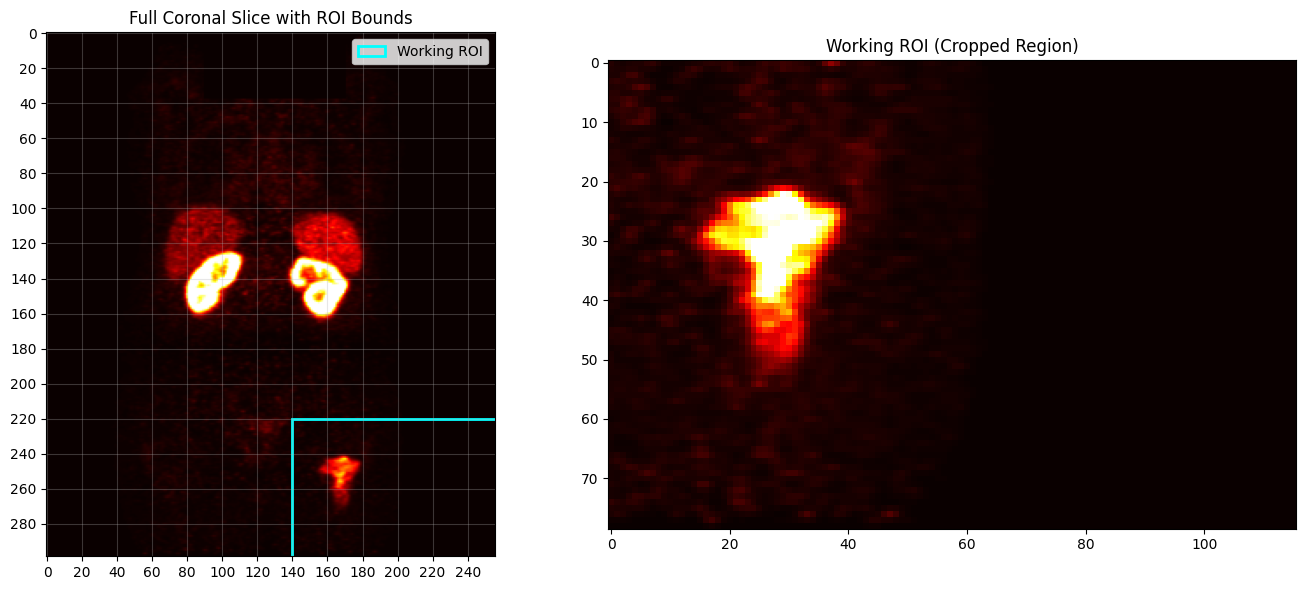

In [24]:
# Extract and display coronal slice
coronal_raw = spect_array[:, CORONAL_SLICE, :]#
coronal_vis = np.fliplr(np.rot90(coronal_raw, 2))# SE ROTAN 180 GRADOS Y SE VOLTEA HORIZONTALMENTE PARA QUE LA IMAGEN CORONAL SE VISUALICE CORRECTAMENTE


# Crop to working region
roi_img = coronal_vis[ROI_CROP[0]:, ROI_CROP[1]:]# se recorta la imagen coronal para obtener la región de interés (ROI) a partir de las coordenadas especificadas en ROI_CROP

print(f" Coronal slice extracted and processed")
print(f"  - Coronal slice index: {CORONAL_SLICE}")
print(f"  - Full coronal shape: {coronal_vis.shape}")
print(f"  - Working ROI shape: {roi_img.shape}")
print(f"  - ROI intensity range: [{roi_img.min():.2f}, {roi_img.max():.2f}]")

# Visualize working ROI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full coronal image
axes[0].imshow(
    coronal_vis,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(coronal_vis, 99)
)

# Coordinate grid
axes[0].set_xticks(np.arange(0, coronal_vis.shape[1], 20))
axes[0].set_yticks(np.arange(0, coronal_vis.shape[0], 20))
axes[0].grid(True, alpha=0.3)

# ROI rectangle
roi_rect = patches.Rectangle(
    (ROI_CROP[1], ROI_CROP[0]),               # (x, y)
    coronal_vis.shape[1] - ROI_CROP[1],      # width
    coronal_vis.shape[0] - ROI_CROP[0],      # height
    linewidth=2,
    edgecolor="cyan",
    facecolor="none",
    label="Working ROI"
)

axes[0].add_patch(roi_rect)

axes[0].set_title("Full Coronal Slice with ROI Bounds")
axes[0].legend()

# Cropped ROI
axes[1].imshow(
    roi_img,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

axes[1].set_title("Working ROI (Cropped Region)")
axes[1].axis("on")

plt.tight_layout()
plt.show()

### ____________________________________________________________________________-

✓ Manual segmentation loaded
  - Segmented voxels (3D): 4828
  - Segmented pixels in ROI: 318


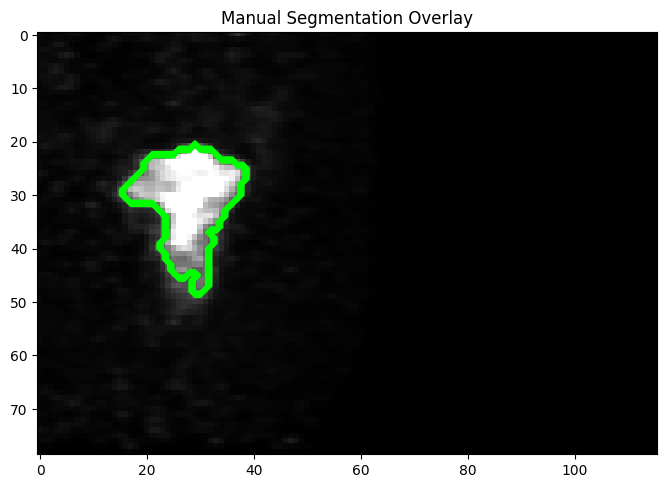

In [25]:
# ==============================================================================
# ! Stage 1.5: Load Manual Segmentation (DICOM SEG)
# ==============================================================================

SEG_PATH = DATA_DIR / "SEGMENTATIONS" / "1-1.dcm"

def load_manual_segmentation(
    seg_path,
    spect_dir,
    spect_array,
    coronal_slice,
    roi_crop
):
    """
    Load DICOM SEG, reconstruct full 3D segmentation volume,
    extract the same coronal plane used by the algorithm,
    and apply identical visualization transforms and ROI crop.
    """

    # Load SEG object
    seg = pydicom.dcmread(str(seg_path))
    seg_array = seg.pixel_array.astype(np.uint8)

    # Build UID -> slice index map from SPECT series
    spect_files = sorted(Path(spect_dir).glob("*.dcm"))

    uid_to_slice = {}

    for idx, f in enumerate(spect_files):

        ds = pydicom.dcmread(
            str(f),
            stop_before_pixels=True
        )

        uid_to_slice[ds.SOPInstanceUID] = idx

    # Determine which SPECT slice corresponds to each SEG frame
    seg_slices = []

    for frame in seg.PerFrameFunctionalGroupsSequence:

        uid = (
            frame.DerivationImageSequence[0]
            .SourceImageSequence[0]
            .ReferencedSOPInstanceUID
        )

        if uid in uid_to_slice:
            seg_slices.append(uid_to_slice[uid])

    # Reconstruct full 3D segmentation volume
    manual_mask_3d = np.zeros_like(
        spect_array,
        dtype=np.uint8
    )

    for frame_idx, spect_idx in enumerate(seg_slices):
        manual_mask_3d[spect_idx] = seg_array[frame_idx]

    # Extract same coronal plane
    manual_coronal_raw = manual_mask_3d[:, coronal_slice, :]

    # Apply same visualization orientation
    manual_coronal_vis = np.flipud(
        np.fliplr(
            np.rot90(manual_coronal_raw, 2)
        )
    )

    # Apply same ROI crop
    manual_mask_roi = manual_coronal_vis[
        roi_crop[0]:,
        roi_crop[1]:
    ]

    return (
        manual_mask_3d,
        manual_coronal_vis,
        manual_mask_roi
    )

# Load manual segmentation
manual_mask_3d, manual_coronal_vis, manual_mask_roi = (
    load_manual_segmentation(
        SEG_PATH,
        SPECT_DIR,
        spect_array,
        CORONAL_SLICE,
        ROI_CROP
    )
)

print("✓ Manual segmentation loaded")
print(f"  - Segmented voxels (3D): {manual_mask_3d.sum()}")
print(f"  - Segmented pixels in ROI: {manual_mask_roi.sum()}")

# Visual verification

plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

plt.contour(
    manual_mask_roi,
    colors="lime",
    linewidths=2
)

plt.title("Manual Segmentation Overlay")
plt.show()

### _____________________________________________________________________________________________

## Stage 2: Initial Lesion Mask (ROI0)

 Initial mask (ROI0) created
  - Threshold: 65% of max = 12639.98
  - Mask size: 76 voxels


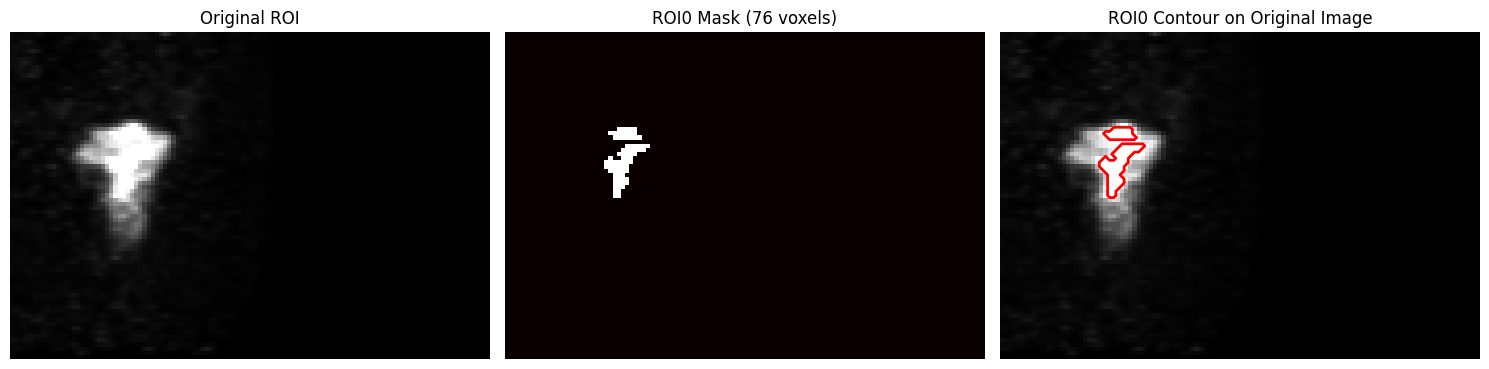

In [26]:
# Create initial lesion mask (ROI0)
threshold = THRESHOLD_PERCENTILE * roi_img.max() 
mask0 = roi_img > threshold # todo voxel con intensidad mayor al umbral se considera parte de la lesión y se marca como True en la máscara binaria mask0

print(f" Initial mask (ROI0) created")
print(f"  - Threshold: {THRESHOLD_PERCENTILE * 100:.0f}% of max = {threshold:.2f}")
print(f"  - Mask size: {mask0.sum()} voxels")

# Visualize initial mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].set_title("Original ROI")
axes[0].axis('off')

axes[1].imshow(mask0, cmap="hot")
axes[1].set_title(f"ROI0 Mask ({mask0.sum()} voxels)")
axes[1].axis('off')

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].set_title("ROI0 Contour on Original Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 3: PyRadiomics Setup & Utility Functions

# Initialize PyRadiomics feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor()  # Crear una instancia del extractor de PyRadiomics con la configuración por defecto
extractor.disableAllFeatures()  # Desactivar todas las características para evitar cálculos innecesarios
extractor.enableFeaturesByName(**{FEATURE_CLASS: [FEATURE_NAME]})  # Habilitar únicamente la característica especificada (ej. firstorder: Median)

print(f"✓ PyRadiomics extractor initialized") 
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")  
print(f"  - Voxel-based extraction enabled") 

In [27]:
# ==============================================================================
# Initialize PyRadiomics feature extractor
# ==============================================================================

settings = {
    "binWidth": BIN_WIDTH,
    "kernelRadius": KERNEL_RADIUS,
    "distances": DISTANCES,
    "weightingNorm": WEIGHTING_NORM,
    "normalize": NORMALIZE
}

if REMOVE_OUTLIERS is not None:
    settings["removeOutliers"] = REMOVE_OUTLIERS

extractor = featureextractor.RadiomicsFeatureExtractor(**settings)

# Enable only the desired feature
extractor.disableAllFeatures()
extractor.enableFeaturesByName(
    **{FEATURE_CLASS: [FEATURE_NAME]}
)

print("✓ PyRadiomics extractor initialized")
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Voxel-based extraction enabled")
print("  - Extraction settings:")
print(f"      binWidth        = {BIN_WIDTH}")
print(f"      kernelRadius    = {KERNEL_RADIUS}")
print(f"      distances       = {DISTANCES}")
print(f"      weightingNorm   = {WEIGHTING_NORM}")
print(f"      normalize       = {NORMALIZE}")
print(f"      removeOutliers  = {REMOVE_OUTLIERS}")


✓ PyRadiomics extractor initialized
  - Feature: ngtdm.Coarseness
  - Voxel-based extraction enabled
  - Extraction settings:
      binWidth        = 25
      kernelRadius    = 1
      distances       = [1]
      weightingNorm   = None
      normalize       = False
      removeOutliers  = None


In [28]:
def reconstruct_voxel_map(result_dict, reference_shape, feature_key):
    """
    result_dict: diccionario de resultados de PyRadiomics que contiene la característica extraída y la bounding box
    reference_shape: la forma de la imagen original
    feature_key: clave de la característica en result_dict (ej. "original_firstorder_M
    
    Tomar el mapa radiomico (que viene en bounding box) y colocarlo de nuevo en 
    la imagen original. ME DA UN ARRAY CON el mapa radiomico voxel-based reubicado en el sistema original de la imagen (80×60), lo que 
    no esta en el bounding box esta llenos de ceros sin filtrar aun con la mascara
    """
    bbox_key = "diagnostics_Mask-original_BoundingBox"  # variable donde PyRadiomics guarda la bounding box
    if bbox_key not in result_dict:  # verifica que la bounding box esté presente en el resultado
        raise ValueError(f"Bounding box not found in result. Available keys: {result_dict.keys()}")  # lanza error si falta
    
    bbox = result_dict[bbox_key]  # extrae la tupla bounding box
    x, y, z, sx, sy, sz = bbox  # desempaqueta las coordenadas y tamaños del bounding box
    
    if feature_key not in result_dict:  # comprueba que la clave de la característica exista en el resultado
        raise ValueError(
            f"Feature key '{feature_key}' not found in result. Available keys: {list(result_dict.keys())}"
        )  # lanza error si la característica no está presente
    feature_img = result_dict[feature_key]  # obtiene la imagen SimpleITK correspondiente a la característica
    median_map = sitk.GetArrayFromImage(feature_img)[0]  # convierte la imagen a numpy y toma la primera (única) z-slice
    
    full_map = np.zeros(reference_shape, dtype=float)  # inicializa el mapa completo con ceros (float)
    
    h, w = median_map.shape  # obtiene alto y ancho del mapa dentro del bounding box
    x0 = x - 1  # convierte la coordenada x de 1-based (PyRadiomics) a 0-based (numpy)
    y0 = y - 1  # convierte la coordenada y de 1-based a 0-based
    
    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map  # inserta el mapa extraído en la posición correspondiente del mapa completo
    
    return full_map, (x0, y0, h, w)  # devuelve el mapa reconstruido y la información de bounding box ajustada

print("✓ Utility function 'reconstruct_voxel_map' defined")  # confirma que la función ha sido definida


✓ Utility function 'reconstruct_voxel_map' defined


## Stage 4: Reference Distribution (ROI0 Voxel-Based Statistics)

✓ Reference distribution computed from ROI0
  - Feature: original_ngtdm_Coarseness
  - Voxels: 76

Mean = 0.0257
Std = 0.0144
Median = 0.0186
MAD = 0.0064
Percentiles = [0.0137, 0.0563]
Tukey = [-0.0102, 0.0591]


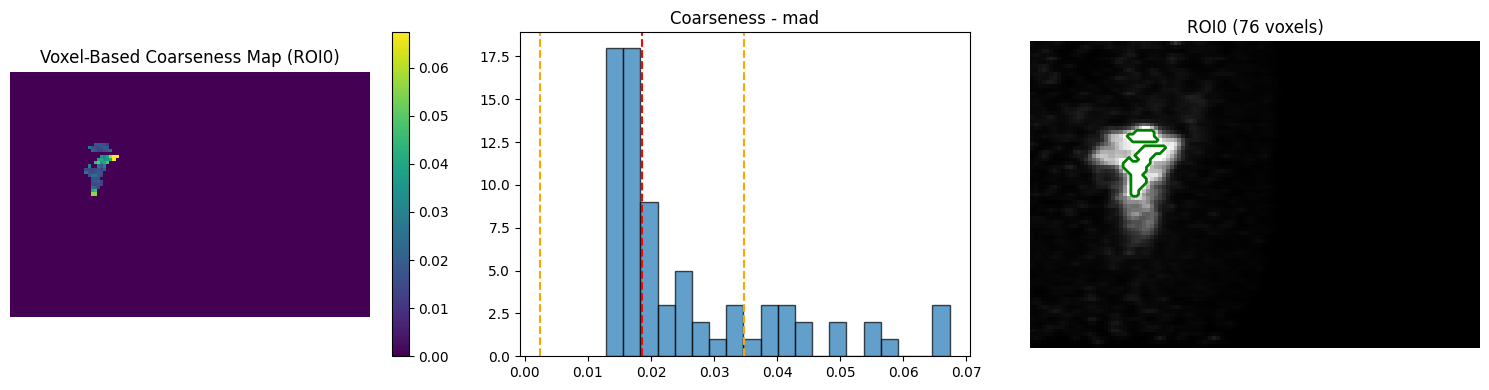

In [29]:
# Extract voxel-based radiomic map for ROI0
# Convert to 3D format required by PyRadiomics
img_3d = roi_img[np.newaxis, :, :].astype(np.float32)
mask0_3d = mask0[np.newaxis, :, :].astype(np.uint8)

sitk_img = sitk.GetImageFromArray(img_3d)
sitk_mask0 = sitk.GetImageFromArray(mask0_3d)

# Extract voxel-based radiomic map
result_roi0 = extractor.execute(sitk_img, sitk_mask0, voxelBased=True)

# Reconstruct full map and extract ROI0 voxel values
voxel_map_roi0, bbox_info = reconstruct_voxel_map(result_roi0, roi_img.shape, FEATURE_KEY)
vals_roi0 = voxel_map_roi0[mask0]  # Extract values only within mask0

# Compute reference statistics, general for the method chosen (mean_std, mad, percentile, tukey)
mean_ref = vals_roi0.mean()
std_ref = vals_roi0.std()

median_ref = np.median(vals_roi0)

mad_ref = np.median(np.abs(vals_roi0 - median_ref))
mad_scaled = 1.4826 * mad_ref

q_low = np.percentile(vals_roi0, PERCENTILE_LOW)
q_high = np.percentile(vals_roi0, PERCENTILE_HIGH)

q1 = np.percentile(vals_roi0, 25)
q3 = np.percentile(vals_roi0, 75)
iqr = q3 - q1

tukey_low = q1 - 1.5 * iqr
tukey_high = q3 + 1.5 * iqr

print(f"✓ Reference distribution computed from ROI0")
print(f"  - Feature: {FEATURE_KEY}")
print(f"  - Voxels: {len(vals_roi0)}")
print(f"")
print(f"Mean = {mean_ref:.4f}")
print(f"Std = {std_ref:.4f}")
print(f"Median = {median_ref:.4f}")
print(f"MAD = {mad_scaled:.4f}")
print(f"Percentiles = [{q_low:.4f}, {q_high:.4f}]")
print(f"Tukey = [{tukey_low:.4f}, {tukey_high:.4f}]")
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(voxel_map_roi0, cmap="viridis")
axes[0].set_title(f"Voxel-Based {FEATURE_NAME} Map (ROI0)")
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])
axes[0].axis('off')

axes[1].hist(vals_roi0, bins=20, edgecolor='k', alpha=0.7)

if ACCEPTANCE_METHOD == "mean_std":

    lower = mean_ref - K_VALUE * std_ref
    upper = mean_ref + K_VALUE * std_ref

    axes[1].axvline(mean_ref, color='r', linestyle='--',
                    label=f"Mean = {mean_ref:.2f}")

    axes[1].axvline(lower, color='orange', linestyle='--',
                    label=f"Lower = {lower:.2f}")

    axes[1].axvline(upper, color='orange', linestyle='--',
                    label=f"Upper = {upper:.2f}")

elif ACCEPTANCE_METHOD == "mad":

    lower = median_ref - ROBUST_K * mad_scaled
    upper = median_ref + ROBUST_K * mad_scaled

    axes[1].axvline(median_ref, color='r', linestyle='--',
                    label=f"Median = {median_ref:.2f}")

    axes[1].axvline(lower, color='orange', linestyle='--',
                    label=f"Lower = {lower:.2f}")

    axes[1].axvline(upper, color='orange', linestyle='--',
                    label=f"Upper = {upper:.2f}")

elif ACCEPTANCE_METHOD == "percentile":

    axes[1].axvline(q_low, color='orange', linestyle='--',
                    label=f"P{PERCENTILE_LOW}")

    axes[1].axvline(q_high, color='orange', linestyle='--',
                    label=f"P{PERCENTILE_HIGH}")

elif ACCEPTANCE_METHOD == "tukey":

    axes[1].axvline(tukey_low, color='orange', linestyle='--',
                    label="Lower Tukey")

    axes[1].axvline(tukey_high, color='orange', linestyle='--',
                    label="Upper Tukey")
axes[1].set_title(
    f"{FEATURE_NAME} - {ACCEPTANCE_METHOD}"
)
axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='g', linewidths=2)
axes[2].set_title(f"ROI0 ({mask0.sum()} voxels)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 5: Iterative Region Growing

In [ ]:
#!/usr/bin/env python
# Iterative region growing with fixed reference statistics

roi_current = mask0.copy()
results = []
history = []

print(f"Starting iterative region growing ({NUM_ITERATIONS} iterations)...\n")

def classify_voxels(values):

    if ACCEPTANCE_METHOD == "mean_std":

        lower = mean_ref - K_VALUE * std_ref
        upper = mean_ref + K_VALUE * std_ref
        return (values >= lower) & (values <= upper)

    elif ACCEPTANCE_METHOD == "mad":

        lower = median_ref - ROBUST_K * mad_scaled
        upper = median_ref + ROBUST_K * mad_scaled
        return (values >= lower) & (values <= upper)

    elif ACCEPTANCE_METHOD == "percentile":

        return (values >= q_low) & (values <= q_high)

    elif ACCEPTANCE_METHOD == "tukey":

        return (values >= tukey_low) & (values <= tukey_high)

    else:
        raise ValueError(f"Unknown acceptance method: {ACCEPTANCE_METHOD}")
    


rejected_forever = np.zeros_like(roi_current, dtype=bool)#!

for iteration in range(1, NUM_ITERATIONS + 1):
    #*_____________________________________________________________________
    mask_current_3d = roi_current.astype(np.uint8)[np.newaxis, :, :]
    sitk_mask_current = sitk.GetImageFromArray(mask_current_3d)
    result_current = extractor.execute(
    sitk_img,
    sitk_mask_current,
    voxelBased=True
    )
    full_map_current, _ = reconstruct_voxel_map(
        result_current,
        roi_img.shape,
        FEATURE_KEY
    )
    
    vals_current = full_map_current[roi_current]
    mean_ref = vals_current.mean()
    std_ref = vals_current.std()

    median_ref = np.median(vals_current)

    mad_ref = np.median(np.abs(vals_current - median_ref))
    mad_scaled = 1.4826 * mad_ref

    q_low = np.percentile(vals_current, PERCENTILE_LOW)
    q_high = np.percentile(vals_current, PERCENTILE_HIGH)

    q1 = np.percentile(vals_current, 25)
    q3 = np.percentile(vals_current, 75)

    iqr = q3 - q1

    tukey_low = q1 - 1.5 * iqr
    tukey_high = q3 + 1.5 * iqr
    print(
    f"Iter {iteration}: "
    f"Mean={mean_ref:.4f} "
    f"Median={median_ref:.4f} "
    f"MAD={mad_scaled:.4f}"
    )
    #*_____________________________________________________________________
    
    
    # Step 1: Generate candidate voxels via dilation
    roi_dilated = binary_dilation(roi_current)
    corona = roi_dilated & (~roi_current) & (~rejected_forever)#!
    
    # Step 2: Compute voxel-based feature map on dilated ROI
    mask_3d = roi_dilated.astype(np.uint8)[np.newaxis, :, :]
    sitk_mask = sitk.GetImageFromArray(mask_3d)
    
    result = extractor.execute(sitk_img, sitk_mask, voxelBased=True)
    
    # Step 3: Reconstruct full-size map from PyRadiomics bounding box
    full_map, _ = reconstruct_voxel_map(result, roi_img.shape, FEATURE_KEY)
    
    # Step 4: Extract radiomic values for corona voxels
    corona_values = full_map[corona]
    
    # Step 5: Classify voxels (accept if within statistical bounds)
    accepted = classify_voxels(corona_values)
    mask_rejected = np.zeros_like(roi_current, dtype=bool)#!
    mask_rejected[corona] = ~accepted

    # Guardar permanentemente los rechazados
    rejected_forever |= mask_rejected
    
    # Step 6: Create mask of accepted voxels
    mask_accepted = np.zeros_like(roi_current, dtype=bool)
    mask_accepted[corona] = accepted
    
    # Step 7: Update ROI with accepted voxels
    roi_new = roi_current | mask_accepted
    
    # Step 8: Store results
    n_accepted = accepted.sum()
    n_rejected = (~accepted).sum()
    
    results.append({
        "Iteration": iteration,
        "Current ROI Size": roi_current.sum(),
        "Corona Size": corona.sum(),
        "Accepted": n_accepted,
        "Rejected": n_rejected,
        "New ROI Size": roi_new.sum()
    })
    
    history.append({
        "iteration": iteration,
        "roi_current": roi_current.copy(),
        "roi_dilated": roi_dilated.copy(),
        "corona": corona.copy(),
        "mask_accepted": mask_accepted.copy(),
        "corona_values": corona_values.copy(),
        "voxel_map": full_map.copy(),
        "mask_rejected": mask_rejected.copy(),
        "rejected_forever": rejected_forever.copy()
    })
    
    # Print progress
    size_increase = roi_new.sum() - roi_current.sum()
    print(f"Iter {iteration:2d}: ROI {roi_current.sum():4d} → {roi_new.sum():4d} "
          f"| Corona: {corona.sum():4d} | Acc: {n_accepted:4d} | Rej: {n_rejected:4d} | "
          f"Growth: {size_increase:+4d}")
    
    # Update for next iteration
    roi_current = roi_new

print("\n✓ Iterative region growing completed!")

# Create results DataFrame
df_results = pd.DataFrame(results)
print("\nResults Summary:")
print(df_results)

Starting iterative region growing (20 iterations)...

Iter  1: ROI   76 →  126 | Corona:   53 | Acc:   50 | Rej:    3 | Growth:  +50
Iter  2: ROI  126 →  170 | Corona:   49 | Acc:   44 | Rej:    5 | Growth:  +44
Iter  3: ROI  170 →  213 | Corona:   47 | Acc:   43 | Rej:    4 | Growth:  +43
Iter  4: ROI  213 →  242 | Corona:   50 | Acc:   29 | Rej:   21 | Growth:  +29
Iter  5: ROI  242 →  264 | Corona:   39 | Acc:   22 | Rej:   17 | Growth:  +22
Iter  6: ROI  264 →  293 | Corona:   33 | Acc:   29 | Rej:    4 | Growth:  +29
Iter  7: ROI  293 →  321 | Corona:   41 | Acc:   28 | Rej:   13 | Growth:  +28
Iter  8: ROI  321 →  344 | Corona:   36 | Acc:   23 | Rej:   13 | Growth:  +23
Iter  9: ROI  344 →  359 | Corona:   30 | Acc:   15 | Rej:   15 | Growth:  +15
Iter 10: ROI  359 →  371 | Corona:   22 | Acc:   12 | Rej:   10 | Growth:  +12
Iter 11: ROI  371 →  380 | Corona:   13 | Acc:    9 | Rej:    4 | Growth:   +9
Iter 12: ROI  380 →  387 | Corona:   11 | Acc:    7 | Rej:    4 | Growth:   +

## Stage 6: Results & Visualizations

In [31]:
# Results summary table
print("\n" + "="*80)
print("ITERATIVE REGION GROWING RESULTS")
print("="*80)
print(df_results.to_string(index=False))
print("="*80)

# Summary statistics
roi_final = history[-1]["roi_current"] | history[-1]["mask_accepted"]
total_growth = roi_final.sum() - mask0.sum()
percent_growth = (total_growth / mask0.sum()) * 100

print(f"\nFinal Summary:")
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Acceptance method: {ACCEPTANCE_METHOD}")
print(f"  - Initial ROI0 size: {mask0.sum()} voxels")
print(f"  - Final ROI size: {roi_final.sum()} voxels")
print(f"  - Total voxels added: {total_growth} voxels ({percent_growth:.1f}% growth)")
print(f"  - Total iterations: {NUM_ITERATIONS}")

if ACCEPTANCE_METHOD == "mean_std":
    print(f"  - Acceptance interval: [{mean_ref - K_VALUE*std_ref:.4f}, {mean_ref + K_VALUE*std_ref:.4f}]")

elif ACCEPTANCE_METHOD == "mad":
    print(f"  - Acceptance interval: [{median_ref - ROBUST_K*mad_scaled:.4f}, {median_ref + ROBUST_K*mad_scaled:.4f}]")

elif ACCEPTANCE_METHOD == "percentile":
    print(f"  - Acceptance interval: [{q_low:.4f}, {q_high:.4f}]")

elif ACCEPTANCE_METHOD == "tukey":
    print(f"  - Acceptance interval: [{tukey_low:.4f}, {tukey_high:.4f}]")


ITERATIVE REGION GROWING RESULTS
 Iteration  Current ROI Size  Corona Size  Accepted  Rejected  New ROI Size
         1                76           53        50         3           126
         2               126           49        44         5           170
         3               170           47        43         4           213
         4               213           50        29        21           242
         5               242           39        22        17           264
         6               264           33        29         4           293
         7               293           41        28        13           321
         8               321           36        23        13           344
         9               344           30        15        15           359
        10               359           22        12        10           371
        11               371           13         9         4           380
        12               380           11         7   

C:\Users\oscar\AppData\Local\Temp\ipykernel_14916\9213125.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  axes[2].contour(mask0, colors='r', linewidths=2, label=f'ROI0 ({mask0.sum()})')
C:\Users\oscar\AppData\Local\Temp\ipykernel_14916\9213125.py:20: UserWarning: The following kwargs were not used by contour: 'label'
  axes[2].contour(roi_final, colors='g', linewidths=2, label=f'Final ({roi_final.sum()})')


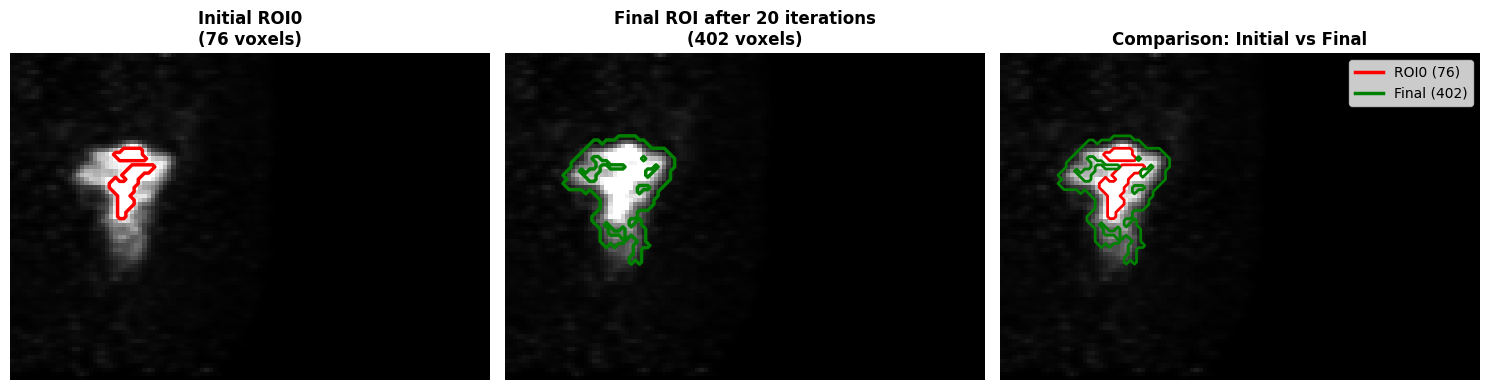

In [32]:
# Visualization: Final ROI evolution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Original image with initial mask
axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].contour(mask0, colors='r', linewidths=2.5)
axes[0].set_title(f"Initial ROI0\n({mask0.sum()} voxels)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Plot 2: Original image with final ROI
axes[1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[1].contour(roi_final, colors='g', linewidths=2.5)
axes[1].set_title(f"Final ROI after {NUM_ITERATIONS} iterations\n({roi_final.sum()} voxels)", 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

# Plot 3: Comparison with overlays
axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2, label=f'ROI0 ({mask0.sum()})')
axes[2].contour(roi_final, colors='g', linewidths=2, label=f'Final ({roi_final.sum()})')

# Create custom legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='r', lw=2.5),
    Line2D([0], [0], color='g', lw=2.5)
]
axes[2].legend(custom_lines, [f'ROI0 ({mask0.sum()})', f'Final ({roi_final.sum()})'], 
               loc='upper right', fontsize=10)
axes[2].set_title("Comparison: Initial vs Final", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_14916\96682997.py:9: UserWarning: The following kwargs were not used by contour: 'label'
  axes[0, 0].contour(mask0, colors='r', linewidths=1.5, linestyles='--', label='ROI0')
C:\Users\oscar\AppData\Local\Temp\ipykernel_14916\96682997.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  axes[0, 0].contour(data_iter["roi_current"], colors='b', linewidths=2, label='Current ROI')
C:\Users\oscar\AppData\Local\Temp\ipykernel_14916\96682997.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(loc='upper right')


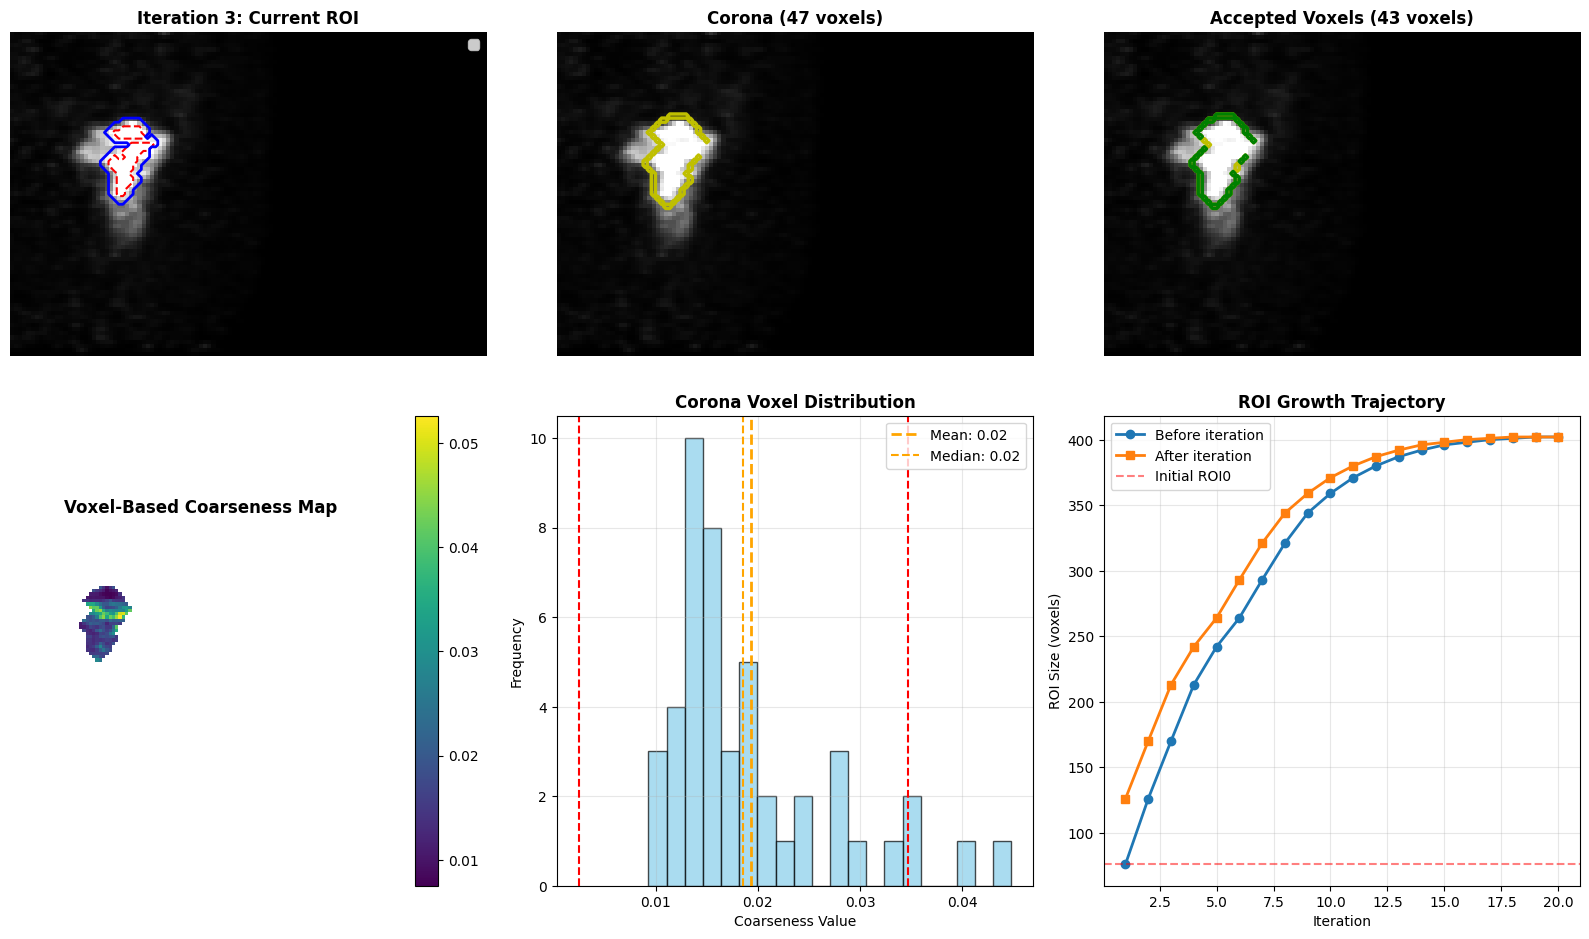

In [33]:
# Detailed visualization of a specific iteration (example: iteration 5)
iter_to_show = min(3, NUM_ITERATIONS)  # Show iteration 5, or last if fewer iterations
data_iter = history[iter_to_show - 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Iteration details
axes[0, 0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 0].contour(mask0, colors='r', linewidths=1.5, linestyles='--', label='ROI0')
axes[0, 0].contour(data_iter["roi_current"], colors='b', linewidths=2, label='Current ROI')
axes[0, 0].set_title(f"Iteration {iter_to_show}: Current ROI", fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].axis('off')

axes[0, 1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 1].contour(data_iter["corona"], colors='y', linewidths=2.5)
axes[0, 1].set_title(f"Corona ({data_iter['corona'].sum()} voxels)", fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0, 2].contour(data_iter["corona"], colors='y', linewidths=2.5)
axes[0, 2].contour(data_iter["mask_accepted"], colors='g', linewidths=2.5)
axes[0, 2].set_title(f"Accepted Voxels ({data_iter['mask_accepted'].sum()} voxels)", fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Radiomic map and statistics
voxel_map = data_iter["voxel_map"]
voxel_map_masked = np.copy(voxel_map)
voxel_map_masked[voxel_map == 0] = np.nan

im = axes[1, 0].imshow(voxel_map_masked, cmap="viridis")
axes[1, 0].set_title(f"Voxel-Based {FEATURE_NAME} Map", fontweight='bold')
plt.colorbar(im, ax=axes[1, 0])
axes[1, 0].axis('off')

corona_vals = data_iter["corona_values"]
axes[1, 1].hist(corona_vals[corona_vals > 0], bins=20, edgecolor='k', alpha=0.7, color='skyblue')
axes[1, 1].axvline(corona_vals[corona_vals > 0].mean(), color='orange', linestyle='--', 
                   linewidth=2, label=f'Mean: {corona_vals[corona_vals > 0].mean():.2f}')

if ACCEPTANCE_METHOD == "mean_std":
    axes[1,1].axvline(mean_ref, color='orange', linestyle='--',
                      label=f"Mean: {mean_ref:.2f}")
    axes[1,1].axvline(mean_ref-K_VALUE*std_ref, color='r', linestyle='--')
    axes[1,1].axvline(mean_ref+K_VALUE*std_ref, color='r', linestyle='--')

elif ACCEPTANCE_METHOD == "mad":
    axes[1,1].axvline(median_ref, color='orange', linestyle='--',
                      label=f"Median: {median_ref:.2f}")
    axes[1,1].axvline(median_ref-ROBUST_K*mad_scaled, color='r', linestyle='--')
    axes[1,1].axvline(median_ref+ROBUST_K*mad_scaled, color='r', linestyle='--')

elif ACCEPTANCE_METHOD == "percentile":
    axes[1,1].axvline(q_low, color='r', linestyle='--',
                      label=f"P{PERCENTILE_LOW}")
    axes[1,1].axvline(q_high, color='r', linestyle='--',
                      label=f"P{PERCENTILE_HIGH}")

elif ACCEPTANCE_METHOD == "tukey":
    axes[1,1].axvline(tukey_low, color='r', linestyle='--',
                      label="Lower fence")
    axes[1,1].axvline(tukey_high, color='r', linestyle='--',
                      label="Upper fence")
axes[1, 1].set_xlabel(f"{FEATURE_NAME} Value")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Corona Voxel Distribution", fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Growth trajectory
iter_range = [r["Iteration"] for r in results]
roi_sizes = [r["Current ROI Size"] for r in results]
new_sizes = [r["New ROI Size"] for r in results]

axes[1, 2].plot(iter_range, roi_sizes, 'o-', linewidth=2, markersize=6, label='Before iteration')
axes[1, 2].plot(iter_range, new_sizes, 's-', linewidth=2, markersize=6, label='After iteration')
axes[1, 2].axhline(mask0.sum(), color='r', linestyle='--', alpha=0.5, label='Initial ROI0')
axes[1, 2].set_xlabel("Iteration")
axes[1, 2].set_ylabel("ROI Size (voxels)")
axes[1, 2].set_title("ROI Growth Trajectory", fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Stage 7: Comparison with manual segmentation

In [34]:
# ==============================================================================
# Stage 7.1: Basic Overlap Analysis
# ==============================================================================

manual = manual_mask_roi.astype(bool)
auto = roi_final.astype(bool)

TP = np.logical_and(manual, auto).sum()
FP = np.logical_and(~manual, auto).sum()
FN = np.logical_and(manual, ~auto).sum()
TN = np.logical_and(~manual, ~auto).sum()

print("="*60)
print("OVERLAP ANALYSIS")
print("="*60)

print(f"Manual voxels:     {manual.sum()}")
print(f"Automatic voxels:  {auto.sum()}")

print()
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")

OVERLAP ANALYSIS
Manual voxels:     318
Automatic voxels:  402

TP: 268
FP: 134
FN: 50
TN: 8712


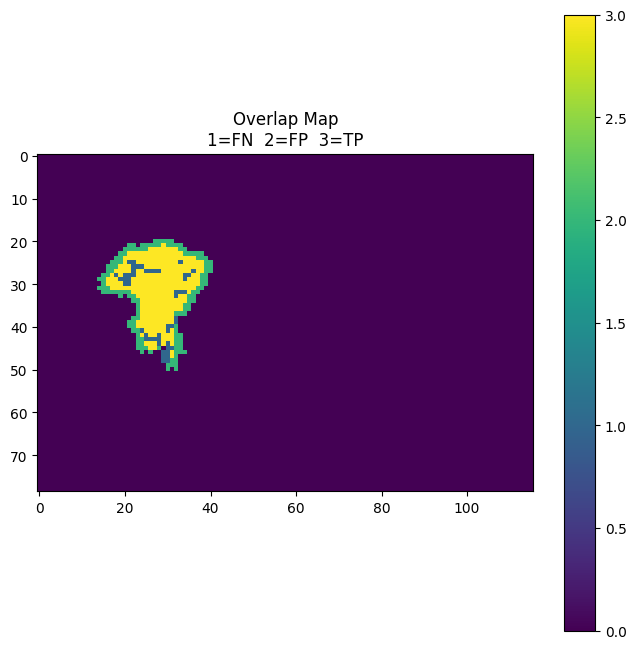

In [35]:
# ==============================================================================
# Visual overlap map
# ==============================================================================

overlap = np.zeros_like(manual, dtype=np.uint8)

overlap[manual & auto] = 3      # TP
overlap[~manual & auto] = 2     # FP
overlap[manual & ~auto] = 1     # FN

plt.figure(figsize=(8,8))

plt.imshow(overlap)

plt.title(
    "Overlap Map\n"
    "1=FN  2=FP  3=TP"
)

plt.colorbar()
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_14916\829081298.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(
C:\Users\oscar\AppData\Local\Temp\ipykernel_14916\829081298.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(


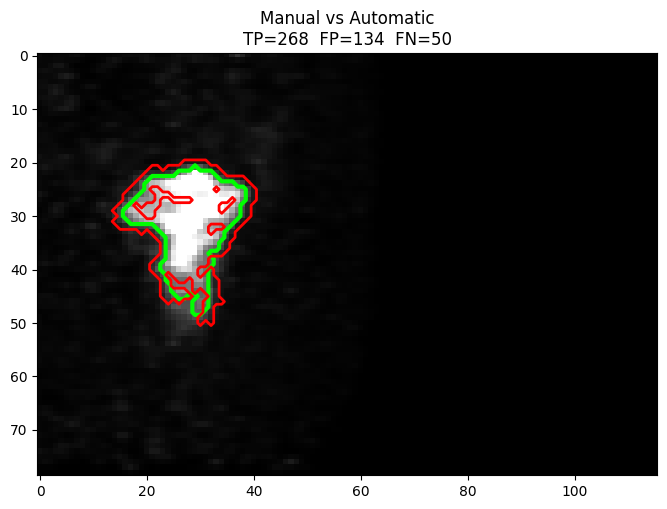

In [36]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(
    manual,
    colors="lime",
    linewidths=3,
    label="Manual"
)

plt.contour(
    auto,
    colors="red",
    linewidths=2,
    label="Automatic"
)

plt.title(
    f"Manual vs Automatic\n"
    f"TP={TP}  FP={FP}  FN={FN}"
)

plt.show()

In [37]:

dice = (2 * TP) / (2 * TP + FP + FN)

iou = TP / (TP + FP + FN)

recall = TP / (TP + FN)

precision = TP / (TP + FP)

metrics_df = pd.DataFrame({
    "Metric": [
        "Dice",
        "IoU",
        "Recall",
        "Precision"
    ],
    "Value": [
        dice,
        iou,
        recall,
        precision
    ]
})

metrics_df

,Metric,Value
0,Dice,0.744444
1,IoU,0.592920
2,Recall,0.842767
3,Precision,0.666667
